In [27]:
import numpy as np
import sys
sys.path.append("/opt/devel/rbyrne/rlb_LWA/LWA_data_preprocessing")
import datetime
import importlib
import os
import subprocess
import ast
import matplotlib.pyplot as plt

In [24]:
def get_bad_ants(year, month, day):
    """
    Adapted from LWA_calibrated.get_bad_antenna_list
    """
    result = subprocess.getoutput(f"python /opt/devel/rbyrne/rlb_LWA/LWA_data_preprocessing/get_bad_ants.py {year} {month} {day}")
    result = result.split("\n")
    result = [line for line in result if line.startswith("get_bandants output:")][0]
    result = result.split("get_bandants output:")[1].strip()
    result = eval(result)
    if np.isfinite(result[0]):
        return result[1]
    else:
        print(
            f"ERROR: No information on bad antennas found for {year}/{month}/{day}."
        )
        return None

In [21]:
ast.literal_eval(("(60419.20842592593, ['LWA-041A', 'LWA-041B'])"))

(60419.20842592593, ['LWA-041A', 'LWA-041B'])

In [23]:
eval("(np.nan, [])")

(nan, [])

In [35]:
dates = os.listdir("/lustre/pipeline/cosmology/82MHz")
dates.extend(os.listdir("/lustre/pipeline/cosmology/concatenated_data/83MHz"))
dates = np.sort(np.unique(dates))
n_flags = []
for date in dates:
    bad_ants = get_bad_ants(date[:4], date[5:7], date[8:10])
    if bad_ants is not None:
        print(f"{date}: {len(bad_ants)}\n")
        n_flags.append(len(bad_ants))
    else:
        print(f"{date}: NO INFO\n")
        n_flags.append(np.nan)

2024-04-18: 53

2024-04-19: 64

2024-04-20: 57

ERROR: No information on bad antennas found for 2024/04/23.
2024-04-23: NO INFO

2024-04-24: 57

2024-04-25: 75

2024-04-26: 56

2024-04-27: 55

ERROR: No information on bad antennas found for 2024/04/29.
2024-04-29: NO INFO

2024-04-30: 54

2024-05-01: 62

ERROR: No information on bad antennas found for 2024/05/05.
2024-05-05: NO INFO

2024-05-06: 57

2024-05-07: 66

2024-05-08: 70

ERROR: No information on bad antennas found for 2024/05/12.
2024-05-12: NO INFO

2024-05-13: 155

2024-05-14: 65

2024-05-15: 58

ERROR: No information on bad antennas found for 2024/05/17.
2024-05-17: NO INFO

2024-05-18: 64

ERROR: No information on bad antennas found for 2024/05/20.
2024-05-20: NO INFO

2024-05-21: 61

2024-05-24: 52

2024-05-25: 76

2024-05-26: 66

ERROR: No information on bad antennas found for 2024/05/28.
2024-05-28: NO INFO

2024-05-29: 70

ERROR: No information on bad antennas found for 2024/06/01.
2024-06-01: NO INFO

2025-01-01: 35


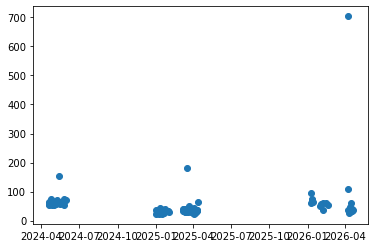

In [ ]:
dates_formatted = [datetime.datetime.strptime(date, "%Y-%m-%d") for date in dates]
dates_formatted[:-20]
plt.scatter(dates_formatted, n_flags)
# Alternatively just look at http://obelix.rice.edu/~ai14/OVRO_LWA/OS3_flagged_signals_trend_interactive.html